# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository.  You have already used this set but this time I have removed  the first column. The set  `banknote_authentication.csv` can be found in the `data`  directory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve


In [2]:
max_components = 12
random_state = 42


In [3]:
data = pd.read_csv('data/banknote_authentication.csv' )


In [4]:
data.head()


,a1,a2,a3,counterfeit
0,12.3784,0.70403,-7.58360,0
1,8.1881,-3.13380,-2.52760,0
2,-10.8679,9.49260,-1.41160,1
3,-8.7903,7.97350,-0.45475,1
4,-5.5167,10.93900,-0.40820,1


## Problem 

### C.

Use k-fold cross validation to find the optimal number of gaussian components for each class. As before calculate the confusion matrix, AUC score and plot the ROC curve for the best classifier. Assume that maximal number of components in each class is 12.  

__Hint__ use the `StratifiedKFold` function from scikit-learn library to generate folds. 

In [5]:
X = data.drop(columns='counterfeit').to_numpy()
y = data['counterfeit'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=random_state)


In [6]:
def fit_classifier(X, y, n_valid, n_counterfeit):

    X_valid = X[y == 0]
    X_counterfeit = X[y == 1]

    model_valid = GaussianMixture(
        n_components=n_valid
    ).fit(X_valid)

    model_counterfeit = GaussianMixture(
        n_components=n_counterfeit
    ).fit(X_counterfeit)

    priors = {
        0: len(X_valid) / len(X),
        1: len(X_counterfeit) / len(X)
    }

    return (model_valid, model_counterfeit), priors


def predict_proba(X, models, priors):
    log_valid = models[0].score_samples(X) + np.log(priors[0])
    log_counterfeit = models[1].score_samples(X) + np.log(priors[1])
    normalizer = np.maximum(log_valid, log_counterfeit)
    valid = np.exp(log_valid - normalizer)
    counterfeit = np.exp(log_counterfeit - normalizer)
    return counterfeit / (valid + counterfeit)


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
results = []

for n_valid in range(1, max_components + 1):
    for n_counterfeit in range(1, max_components + 1):
        aucs = []
        for train_idx, valid_idx in cv.split(X_train, y_train):
            models, priors = fit_classifier(
                X_train[train_idx], y_train[train_idx], n_valid, n_counterfeit
            )
            proba = predict_proba(X_train[valid_idx], models, priors)
            aucs.append(roc_auc_score(y_train[valid_idx], proba))
        results.append([n_valid, n_counterfeit, np.mean(aucs)])

cv_results = pd.DataFrame(
    results, columns=['valid_components', 'counterfeit_components', 'mean_auc']
).sort_values('mean_auc', ascending=False)

cv_results.head(10)


,valid_components,counterfeit_components,mean_auc
142,12,11,0.992957
116,10,9,0.992809
139,12,8,0.992593
95,8,12,0.992390
104,9,9,0.992355
119,10,12,0.992321
130,11,11,0.992263
131,11,12,0.992209
140,12,9,0.991823
106,9,11,0.991812


In [8]:
best_valid, best_counterfeit = cv_results.iloc[0][[
    'valid_components', 'counterfeit_components'
]].astype(int)

best_valid, best_counterfeit


(12, 11)

In [9]:
models, priors = fit_classifier(X_train, y_train, best_valid, best_counterfeit)
test_proba = predict_proba(X_test, models, priors)
test_pred = (test_proba >= 0.5).astype(int)

print('AUC:', roc_auc_score(y_test, test_proba))
pd.DataFrame(
    confusion_matrix(y_test, test_pred),
    index=['actual valid', 'actual counterfeit'],
    columns=['predicted valid', 'predicted counterfeit'],
)


AUC: 0.9930354655523412


,predicted valid,predicted counterfeit
actual valid,146,7
actual counterfeit,6,116


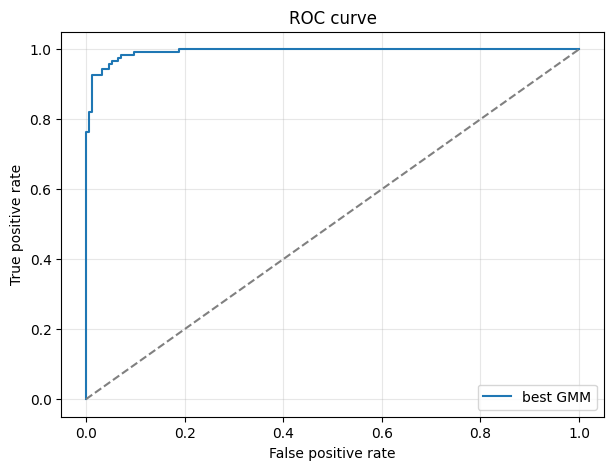

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, test_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label='best GMM')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## D.  

Assume that 1% of all the customers in your store try to pay with a counterfeit 100PLN bill. If you accept the counterfeit bill you loose 100PLN. If you reject a valid bill,  you may loose the purchase, you estimate this loss as 15PLN on average. For each of the three classifiers find the threshold that minimises your losses and calculates the minimum loss for each classifier. Show the optimal classifiers points on the ROC curves.

In [11]:
same_results = []

for n in range(1, max_components + 1):
    aucs = []
    for train_idx, valid_idx in cv.split(X_train, y_train):
        models, priors = fit_classifier(X_train[train_idx], y_train[train_idx], n, n)
        proba = predict_proba(X_train[valid_idx], models, priors)
        aucs.append(roc_auc_score(y_train[valid_idx], proba))
    same_results.append([n, np.mean(aucs)])

same_results = pd.DataFrame(same_results, columns=['components', 'mean_auc'])
best_same = int(same_results.sort_values('mean_auc', ascending=False).iloc[0]['components'])
best_same


10

In [12]:
classifiers = {
    '1 component for each class': (1, 1),
    'same number of components': (best_same, best_same),
    'separate number of components': (best_valid, best_counterfeit),
}

p_counterfeit = 0.01
loss_counterfeit_accepted = 100
loss_valid_rejected = 15
loss_results = []
roc_curves = {}

for name, (n_valid, n_counterfeit) in classifiers.items():
    models, priors = fit_classifier(X_train, y_train, n_valid, n_counterfeit)
    proba = predict_proba(X_test, models, priors)
    fpr, tpr, thresholds = roc_curve(y_test, proba)

    loss = (
        p_counterfeit * (1 - tpr) * loss_counterfeit_accepted
        + (1 - p_counterfeit) * fpr * loss_valid_rejected
    )
    best_idx = np.argmin(loss)

    loss_results.append([
        name,
        n_valid,
        n_counterfeit,
        thresholds[best_idx],
        loss[best_idx],
        fpr[best_idx],
        tpr[best_idx],
    ])
    roc_curves[name] = (fpr, tpr, thresholds, best_idx)

loss_results = pd.DataFrame(
    loss_results,
    columns=['classifier', 'valid_components', 'counterfeit_components',
             'best_threshold', 'minimum_loss', 'fpr', 'tpr'],
).sort_values('minimum_loss')

loss_results


,classifier,valid_components,counterfeit_components,best_threshold,minimum_loss,fpr,tpr
2,separate number of components,12,11,0.926572,0.139344,0.000000,0.860656
1,same number of components,10,10,0.851162,0.195419,0.006536,0.901639
0,1 component for each class,1,1,0.992941,0.893443,0.000000,0.106557


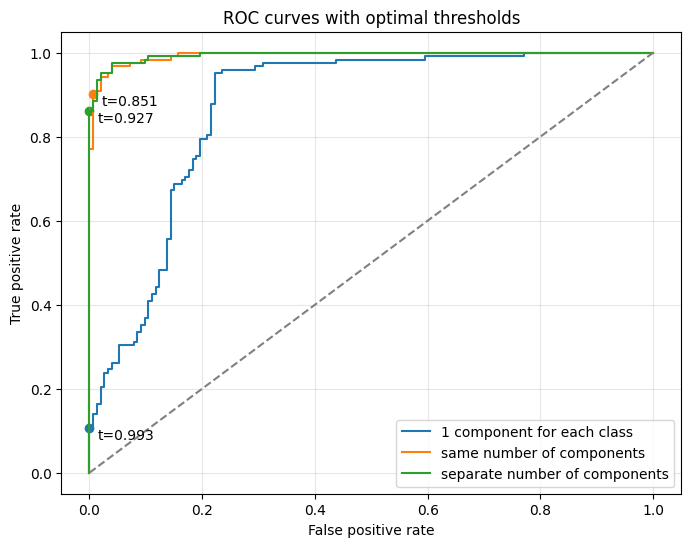

In [13]:
plt.figure(figsize=(8, 6))

for name, (fpr, tpr, thresholds, best_idx) in roc_curves.items():
    plt.plot(fpr, tpr, label=name)
    plt.scatter(fpr[best_idx], tpr[best_idx])
    plt.annotate(
        f't={thresholds[best_idx]:.3f}',
        (fpr[best_idx], tpr[best_idx]),
        textcoords='offset points',
        xytext=(6, -8),
    )

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curves with optimal thresholds')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
